#  Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForMaskedLM
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# Constants

FRACTION_SAMPLE = 0.5  # Use a fraction of the data for faster experimentation
RANDOM_STATE = 42

# Dataset

Load and sample the dataset

In [3]:
 # Load data
df = pd.read_csv("./data/preprocessed/steam_reviews_preprocessed.csv")

# Use a balanced sample for faster experimentation: all funny + equal random not-funny
funny_df = df[df["label_is_funny_binary"] == 1].sample(frac=FRACTION_SAMPLE, random_state=RANDOM_STATE)
not_funny_df = df[df["label_is_funny_binary"] == 0].sample(n=len(funny_df), random_state=RANDOM_STATE)
sample = pd.concat([funny_df, not_funny_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Sample size: {len(sample):,}  |  Funny: {sample['label_is_funny_binary'].sum():,}  |  Not Funny: {(sample['label_is_funny_binary'] == 0).sum():,}")

Sample size: 3,808  |  Funny: 1,904  |  Not Funny: 1,904


In [4]:
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

#  Predictions

## Single-Review Spot Check

Run a single prediction for three representative reviews:
1. The review with the **highest** `review_votes_funny`
2. A review with an **average** (median) `review_votes_funny`
3. A review with **zero** `review_votes_funny`

In [5]:
def predict_single_review(row, prompt, tokenizer, model, device, funny_words, not_funny_words, top_k=10, max_length=512):
    """Run a masked-LM prediction for a single review and print detailed results."""
    target_words = funny_words + not_funny_words
    target_ids = {w: tokenizer.convert_tokens_to_ids(w) for w in target_words}
    mask_id = tokenizer.mask_token_id

    prompt_token_count = len(tokenizer.encode(prompt, add_special_tokens=False))
    max_review_tokens = max_length - prompt_token_count - 2

    text = row["review_text_cleaned"]
    review_ids = tokenizer.encode(text, add_special_tokens=False)[:max_review_tokens]
    review_text = tokenizer.decode(review_ids, skip_special_tokens=True)
    combined = f"{review_text} {prompt}"

    inputs = tokenizer(combined, return_tensors="pt", truncation=True, max_length=max_length).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits.squeeze(0)

    mask_pos = (inputs["input_ids"].squeeze(0) == mask_id).nonzero(as_tuple=False).item()
    probs = torch.softmax(logits[mask_pos], dim=-1)

    top_probs, top_indices = probs.topk(top_k)
    top_tokens = tokenizer.convert_ids_to_tokens(top_indices.cpu().tolist())
    top_k_list = list(zip(top_tokens, [round(p, 6) for p in top_probs.cpu().tolist()]))

    target_scores = {w: round(probs[tid].item(), 6) for w, tid in target_ids.items()}
    funny_sum = sum(target_scores[w] for w in funny_words)
    not_funny_sum = sum(target_scores[w] for w in not_funny_words)

    return {
        "top_k": top_k_list,
        "target_scores": target_scores,
        "funny_sum": round(funny_sum, 6),
        "not_funny_sum": round(not_funny_sum, 6),
    }


def spot_check_reviews(sample, prompt, tokenizer, model, device, funny_words, not_funny_words):
    """Pick three representative reviews and run predictions on each."""

    # 1. Highest funny votes
    row_max = sample.loc[sample["review_votes_funny"].idxmax()]

    # 2. Median funny votes (closest to median)
    median_votes = sample["review_votes_funny"].median()
    row_med = sample.iloc[(sample["review_votes_funny"] - median_votes).abs().argsort().iloc[0]]

    # 3. Zero funny votes (random pick)
    zero_df = sample[sample["review_votes_funny"] == 0]
    row_zero = zero_df.sample(n=1, random_state=RANDOM_STATE).iloc[0]

    picks = [
        ("HIGHEST funny votes", row_max),
        ("MEDIAN funny votes", row_med),
        ("ZERO funny votes",   row_zero),
    ]

    print(f"Prompt: \"{prompt}\"\n")
    for label, row in picks:
        result = predict_single_review(row, prompt, tokenizer, model, device, funny_words, not_funny_words)
        print(f"=== {label} ===")
        print(f"  Review ID : {row['review_id']}")
        print(f"  Game      : {row['app_name']}")
        print(f"  Funny Votes: {row['review_votes_funny']}  |  Label: {'Funny' if row['label_is_funny_binary'] == 1 else 'Not Funny'}")
        print(f"  Text      : {row['review_text_cleaned']}")
        print(f"  Top-{len(result['top_k'])}: {result['top_k']}")
        funny_str = ', '.join(f"{w}: {result['target_scores'][w]}" for w in funny_words)
        not_funny_str = ', '.join(f"{w}: {result['target_scores'][w]}" for w in not_funny_words)
        print(f"  Funny     : {{{funny_str}}}  SUM={result['funny_sum']}")
        print(f"  Not Funny : {{{not_funny_str}}}  SUM={result['not_funny_sum']}")
        print()


### Masked-token prediction for “funny vs not funny” word sets (batched)

`get_mask_predictions(...)` runs a masked-language model over a list of review texts by appending a `prompt` that **must contain `[MASK]`**. For each review, it finds the `[MASK]` position and:

- returns the **top-k predicted tokens** at the mask with their probabilities
- extracts probabilities for a **target vocabulary** (`funny_words + not_funny_words`)
- computes aggregate scores: `funny_sum` and `not_funny_sum` (sums of the respective target-word probabilities)

The function **pre-truncates** reviews so the prompt (and `[MASK]`) is never truncated, and processes inputs in **GPU-friendly batches**. It also prints a small debug preview (first 5 funny / not-funny examples from `sample`) before returning a list of per-text result dicts.


In [6]:
def get_mask_predictions(texts, prompt, tokenizer, model, device, funny_words, not_funny_words, top_k=5, max_length=512, batch_size=32):
    """
    For each review, append `prompt` (which must contain [MASK]),
    then return the top-k predicted words at the [MASK] position
    and the probabilities for every word in TARGET_WORDS.

    Processes texts in batches for faster GPU execution.

    Returns a list of dicts, one per text:
        {
            "top_k": [(word, prob), ...],          # top-k predictions
            "target_scores": {word: prob, ...},     # scores for TARGET_WORDS
            "funny_sum": float,                     # sum of funny word probs
            "not_funny_sum": float,                 # sum of not-funny word probs
        }
    """
    target_words = funny_words + not_funny_words
    target_ids = {w: tokenizer.convert_tokens_to_ids(w) for w in target_words}
    target_id_tensor = torch.tensor([target_ids[w] for w in target_words], device=device)
    mask_id = tokenizer.mask_token_id

    # Reserve tokens for: [CLS] + prompt tokens + [SEP]
    prompt_token_count = len(tokenizer.encode(prompt, add_special_tokens=False))
    max_review_tokens = max_length - prompt_token_count - 2

    # Pre-truncate all reviews so the prompt (with [MASK]) is never cut off
    combined_texts = []
    for text in texts:
        review_ids = tokenizer.encode(text, add_special_tokens=False)[:max_review_tokens]
        review_text = tokenizer.decode(review_ids, skip_special_tokens=True)
        combined_texts.append(f"{review_text} {prompt}")

    results = []
    num_batches = (len(combined_texts) + batch_size - 1) // batch_size

    for batch_idx in tqdm(range(num_batches), desc="Predicting (batched)"):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(combined_texts))
        batch_texts = combined_texts[start:end]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True,
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits  # (batch, seq_len, vocab)

        input_ids = inputs["input_ids"]  # (batch, seq_len)

        # Find [MASK] positions for each item in the batch
        mask_positions = (input_ids == mask_id).nonzero(as_tuple=False)  # (N, 2) -> [batch_idx, seq_pos]

        for i in range(len(batch_texts)):
            # Get the mask position for this item
            item_masks = mask_positions[mask_positions[:, 0] == i]
            mask_pos = item_masks[0, 1].item()

            probs = torch.softmax(logits[i, mask_pos], dim=-1)

            # Top-k predictions
            top_probs, top_indices = probs.topk(top_k)
            top_tokens = tokenizer.convert_ids_to_tokens(top_indices.cpu().tolist())
            top_k_list = list(zip(top_tokens, [round(p, 6) for p in top_probs.cpu().tolist()]))

            # Target-word scores (vectorized lookup)
            target_probs = probs[target_id_tensor].cpu().tolist()
            target_scores = {w: round(p, 6) for w, p in zip(target_words, target_probs)}

            funny_sum = sum(target_scores[w] for w in funny_words)
            not_funny_sum = sum(target_scores[w] for w in not_funny_words)

            results.append({
                "top_k": top_k_list,
                "target_scores": target_scores,
                "funny_sum": round(funny_sum, 6),
                "not_funny_sum": round(not_funny_sum, 6),
            })

    print(f"\nResults: {len(results)}")

    # Print first 5 funny reviews
    funny_indices = sample[sample["label_is_funny_binary"] == 1].index[:5]
    print("=== FUNNY REVIEWS ===\n")
    for idx in funny_indices:
        i = sample.index.get_loc(idx)
        label = "Funny" if sample["label_is_funny_binary"].iloc[i] == 1 else "Not Funny"
        print(f"--- Review {sample['review_id'].iloc[i]} Game: {sample['app_name'].iloc[i]} ---")
        print(f"Funny Votes: {sample['review_votes_funny'].iloc[i]} --- label: [{label}]")
        print(f"Text: {sample['review_text_cleaned'].iloc[i][:200]}...")
        print(f"Top-5: {results[i]['top_k']}")
        funny_scores = ', '.join([f"{w}: {results[i]['target_scores'][w]}" for w in funny_words])
        print(f"Funny:     {{{funny_scores}}}  SUM={results[i]['funny_sum']}")
        not_funny_scores = ', '.join([f"{w}: {results[i]['target_scores'][w]}" for w in not_funny_words])
        print(f"Not Funny: {{{not_funny_scores}}}  SUM={results[i]['not_funny_sum']}")
        print()
    
    # Print first 5 not funny reviews
    not_funny_indices = sample[sample["label_is_funny_binary"] == 0].index[:5]
    print("\n=== NOT FUNNY REVIEWS ===\n")
    for idx in not_funny_indices:
        i = sample.index.get_loc(idx)
        label = "Funny" if sample["label_is_funny_binary"].iloc[i] == 1 else "Not Funny"
        print(f"--- Review {sample['review_id'].iloc[i]} Game: {sample['app_name'].iloc[i]} ---")
        print(f"Funny Votes: {sample['review_votes_funny'].iloc[i]} --- label: [{label}]")
        print(f"Text: {sample['review_text_cleaned'].iloc[i][:200]}...")
        print(f"Top-5: {results[i]['top_k']}")
        funny_scores = ', '.join([f"{w}: {results[i]['target_scores'][w]}" for w in funny_words])
        print(f"Funny:     {{{funny_scores}}}  SUM={results[i]['funny_sum']}")
        not_funny_scores = ', '.join([f"{w}: {results[i]['target_scores'][w]}" for w in not_funny_words])
        print(f"Not Funny: {{{not_funny_scores}}}  SUM={results[i]['not_funny_sum']}")

    return results

In [7]:
texts = sample["review_text_cleaned"].tolist()


### Prompt: "This review is [MASK]"

A prompt where various words could fit the mask. Not just such classifing the prompt as funny or not funny

In [8]:
prompt1 = "This review is [MASK]."
funny_words1 = ["funny", "hilarious", "humorous", "witty", "comedic", "amusing"]
not_funny_words1 = ["boring", "serious", "normal", "ordinary", "dull", "generic"]
results_p1 = get_mask_predictions(texts, prompt1, tokenizer, model, device, funny_words1, not_funny_words1)



Token indices sequence length is longer than the specified maximum sequence length for this model (807 > 512). Running this sequence through the model will result in indexing errors


Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('positive', 0.358578), ('good', 0.186822), ('excellent', 0.063149), ('interesting', 0.043352), ('great', 0.031145)]
Funny:     {funny: 0.001311, hilarious: 0.000228, humorous: 0.000792, witty: 8.5e-05, comedic: 9e-06, amusing: 0.000265}  SUM=0.00269
Not Funny: {boring: 0.000399, serious: 0.000264, normal: 0.000487, ordinary: 0.000125, dull: 0.000294, generic: 3e-05}  SUM=0.001599

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-5: [('positiv

In [9]:
spot_check_reviews(sample, prompt1, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "This review is [MASK]."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('over', 0.073041), ('interesting', 0.043117), ('important', 0.027981), ('true', 0.024792), ('good', 0.021779), ('amazing', 0.021485), ('done', 0.01793), ('great', 0.016358), ('finished', 0.016198), ('bad', 0.014409)]
  Funny     : {funny: 0.005556, hilarious: 0.004182, humorous: 0.000223, witty: 3.9e-05, c

### Prompt: "This review is meant to be [MASK]."

In [10]:
prompt2 = "This review is meant to be [MASK]."
results_p2 = get_mask_predictions(texts, prompt2, tokenizer, model, device, funny_words1, not_funny_words1)

Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('positive', 0.110397), ('interesting', 0.110027), ('humorous', 0.071809), ('entertaining', 0.063971), ('fun', 0.056365)]
Funny:     {funny: 0.011858, hilarious: 0.000191, humorous: 0.071809, witty: 0.001225, comedic: 0.000415, amusing: 0.004228}  SUM=0.089726
Not Funny: {boring: 0.000895, serious: 0.011282, normal: 0.000149, ordinary: 0.000171, dull: 0.000539, generic: 0.000109}  SUM=0.013145

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-

In [11]:
spot_check_reviews(sample, prompt2, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "This review is meant to be [MASK]."



=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('fun', 0.090376), ('interesting', 0.075858), ('good', 0.053413), ('funny', 0.047581), ('special', 0.033967), ('entertaining', 0.026754), ('different', 0.025046), ('true', 0.02177), ('real', 0.01467), ('unique', 0.013847)]
  Funny     : {funny: 0.047581, hilarious: 0.000556, humorous: 0.004604, witty: 0.000143, comedic: 0.000176, amusing: 0

### Prompt: "Most people would find this review [MASK]."

In [12]:
prompt3 = "Most people would find this review [MASK]."
results_p3 = get_mask_predictions(texts, prompt3, tokenizer, model, device, funny_words1, not_funny_words1)

Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('interesting', 0.517611), ('entertaining', 0.050009), ('boring', 0.047915), ('funny', 0.026117), ('fascinating', 0.020946)]
Funny:     {funny: 0.026117, hilarious: 0.006041, humorous: 0.009117, witty: 0.000139, comedic: 8e-06, amusing: 0.018516}  SUM=0.059938
Not Funny: {boring: 0.047915, serious: 0.000118, normal: 9.5e-05, ordinary: 2.1e-05, dull: 0.001898, generic: 1.6e-05}  SUM=0.050063

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-5: 

In [13]:
spot_check_reviews(sample, prompt3, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "Most people would find this review [MASK]."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('boring', 0.223343), ('ridiculous', 0.053842), ('amusing', 0.04751), ('hilarious', 0.044677), ('interesting', 0.039173), ('unfair', 0.036379), ('disgusting', 0.02911), ('fascinating', 0.026272), ('funny', 0.025786), ('pointless', 0.015381)]
  Funny     : {funny: 0.025786, hilarious: 0.0

### Prompt: "The author wrote this to be [MASK]."

In [14]:
prompt4 = "The author wrote this to be [MASK]."
results_p4 = get_mask_predictions(texts, prompt4, tokenizer, model, device, funny_words1, not_funny_words1)

Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('fun', 0.316537), ('interesting', 0.102166), ('easy', 0.047862), ('simple', 0.035795), ('neat', 0.028566)]
Funny:     {funny: 0.010024, hilarious: 0.000527, humorous: 0.013971, witty: 0.00027, comedic: 0.000109, amusing: 0.004912}  SUM=0.029813
Not Funny: {boring: 0.000639, serious: 0.00238, normal: 0.000265, ordinary: 4e-05, dull: 0.000176, generic: 2e-05}  SUM=0.00352

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-5: [('simple', 0.127203

In [15]:
spot_check_reviews(sample, prompt4, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "The author wrote this to be [MASK]."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('true', 0.403037), ('interesting', 0.035766), ('easy', 0.03378), ('neat', 0.031196), ('simple', 0.015964), ('fun', 0.013752), ('fiction', 0.012811), ('clear', 0.012096), ('ironic', 0.011642), ('perfect', 0.011561)]
  Funny     : {funny: 0.007286, hilarious: 0.000178, humorous: 0.003292, witty:

### Prompt: "The writer was trying to be [MASK]."

In [16]:
prompt5 = "The writer was trying to be [MASK]."
results_p5 = get_mask_predictions(texts, prompt5, tokenizer, model, device, funny_words1, not_funny_words1)

Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('funny', 0.097135), ('serious', 0.076401), ('helpful', 0.053373), ('cool', 0.049948), ('friendly', 0.041797)]
Funny:     {funny: 0.097135, hilarious: 0.000405, humorous: 0.010802, witty: 0.001795, comedic: 0.000247, amusing: 0.002792}  SUM=0.113176
Not Funny: {boring: 0.000649, serious: 0.076401, normal: 0.002499, ordinary: 0.000269, dull: 0.00022, generic: 3.1e-05}  SUM=0.080069

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-5: [('creativ

In [17]:
spot_check_reviews(sample, prompt5, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "The writer was trying to be [MASK]."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('nice', 0.085517), ('helpful', 0.046167), ('kind', 0.043173), ('good', 0.037052), ('smart', 0.028429), ('funny', 0.02806), ('clever', 0.027587), ('patient', 0.023007), ('fair', 0.019679), ('strong', 0.018956)]
  Funny     : {funny: 0.02806, hilarious: 0.000255, humorous: 0.000529, witty: 0.000

### Prompt: "This was written in a [MASK] way."

In [18]:
prompt6 = "This was written in a [MASK] way."
results_p6 = get_mask_predictions(texts, prompt6, tokenizer, model, device, funny_words1, not_funny_words1)

Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('different', 0.208512), ('simple', 0.122805), ('nice', 0.053179), ('similar', 0.033422), ('good', 0.026022)]
Funny:     {funny: 0.021636, hilarious: 8.6e-05, humorous: 0.014419, witty: 0.00064, comedic: 0.001028, amusing: 0.000156}  SUM=0.037965
Not Funny: {boring: 0.000116, serious: 0.007892, normal: 0.003062, ordinary: 1.9e-05, dull: 0.000161, generic: 0.000338}  SUM=0.011588

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics added before releasing bug fixes and essential patches that were promised....
Top-5: [('simple', 

In [19]:
spot_check_reviews(sample, prompt6, tokenizer, model, device, funny_words1, not_funny_words1)

Prompt: "This was written in a [MASK] way."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('different', 0.12523), ('new', 0.096778), ('bad', 0.07867), ('big', 0.033207), ('good', 0.032184), ('terrible', 0.025906), ('strange', 0.024477), ('great', 0.0187), ('sad', 0.017185), ('positive', 0.016544)]
  Funny     : {funny: 0.009828, hilarious: 0.000335, humorous: 0.001854, witty: 7.1e-05,

### Prompt: "This review is [MASK] funny."

A prompt where words could fit that classify the humor level of the review. e.g. very, slightly, incredibly, somewhat, barely, not etc.

In [20]:
prompt7 = "This review is [MASK] funny."
funny_words7 = ["slightly", "very", "totally", "extremely", "incredibly", "absolutely", "genuinely", "truly", "remarkably", "undeniably"]
not_funny_words7 = ["somewhat", "barely", "hardly", "mildly", "not", "scarcely", "marginally"]
results_p7 = get_mask_predictions(texts, prompt7, tokenizer, model, device, funny_words7, not_funny_words7)



Predicting (batched):   0%|          | 0/119 [00:00<?, ?it/s]


Results: 3808
=== FUNNY REVIEWS ===

--- Review 129841982 Game: Brotato ---
Funny Votes: 11 --- label: [Funny]
Text: Kind of interesting.
There is a little "addictive", like smoking "Cannabis / weed".
Played for 3-4 hours without realizing it
However, once you close the game, you don't want to open it again.
7/10...
Top-5: [('very', 0.522441), ('really', 0.141661), ('pretty', 0.068393), ('quite', 0.054159), ('not', 0.037848)]
Funny:     {slightly: 0.002105, very: 0.522441, totally: 0.002418, extremely: 0.013865, incredibly: 0.003934, absolutely: 0.000666, genuinely: 0.001243, truly: 0.002485, remarkably: 0.000422, undeniably: 6e-06}  SUM=0.549585
Not Funny: {somewhat: 0.002967, barely: 0.000122, hardly: 0.001048, mildly: 0.000892, not: 0.037848, scarcely: 3e-06, marginally: 6e-06}  SUM=0.042886

--- Review 208140660 Game: Battlefield™ 6 ---
Funny Votes: 15 --- label: [Funny]
Text: Lasted exactly 18 days as a "grounded" Battlefield experience. Battle pass and tacky money grab cosmetics

In [21]:
spot_check_reviews(sample, prompt6, tokenizer, model, device, funny_words7, not_funny_words7)

Prompt: "This was written in a [MASK] way."

=== HIGHEST funny votes ===
  Review ID : 21525836
  Game      : Factorio
  Funny Votes: 2089  |  Label: Funny
  Text      : I got Factorio out of boredom. You see, I'm sick, I got the flu so I'm home and none of my usual games are doing it for me. So I got Factorio. 25 bucks, 350 MB? The hell is this? I feel I got robbed. So I give it a whirl. 14 hours later I stumble into the kitchen for my first meal of the day. Bloodshot eyes, head throbbing, ears buzzing with the sound of inserters doing their thing and then I go to sleep. I can't sleep because all I dream about is building a better automated factory. 
10/10 would ruin my life again.
  Top-10: [('different', 0.12523), ('new', 0.096778), ('bad', 0.07867), ('big', 0.033207), ('good', 0.032184), ('terrible', 0.025906), ('strange', 0.024477), ('great', 0.0187), ('sad', 0.017185), ('positive', 0.016544)]
  Funny     : {slightly: 3e-06, very: 0.000155, totally: 7e-06, extremely: 0.0, incredib

# Evaluation


=== PROMPT COMPARISON ===
                     prompt  pearson_diff  spearman_diff  pearson_ratio  spearman_ratio  f1_diff  f1_ratio  roc_auc_diff  roc_auc_ratio  avg_precision_diff  avg_precision_ratio
P4: wrote this to be [MASK]      0.093949       0.105109      -0.041242        0.048730 0.657964  0.657964      0.560685       0.528134            0.566816             0.550469
P6: written in a [MASK] way      0.032437       0.024951      -0.022468       -0.004657 0.633016  0.633016      0.514405       0.497311            0.528057             0.514407
     P2: meant to be [MASK]      0.027607      -0.012937      -0.056679       -0.030772 0.651312  0.651312      0.492531       0.482234            0.516108             0.499368
       P3: find this [MASK]     -0.097946      -0.105939      -0.113343       -0.126676 0.295211  0.295211      0.438836       0.426864            0.469137             0.466394
    P5: trying to be [MASK]     -0.133624      -0.203444      -0.206272       -0.203162 

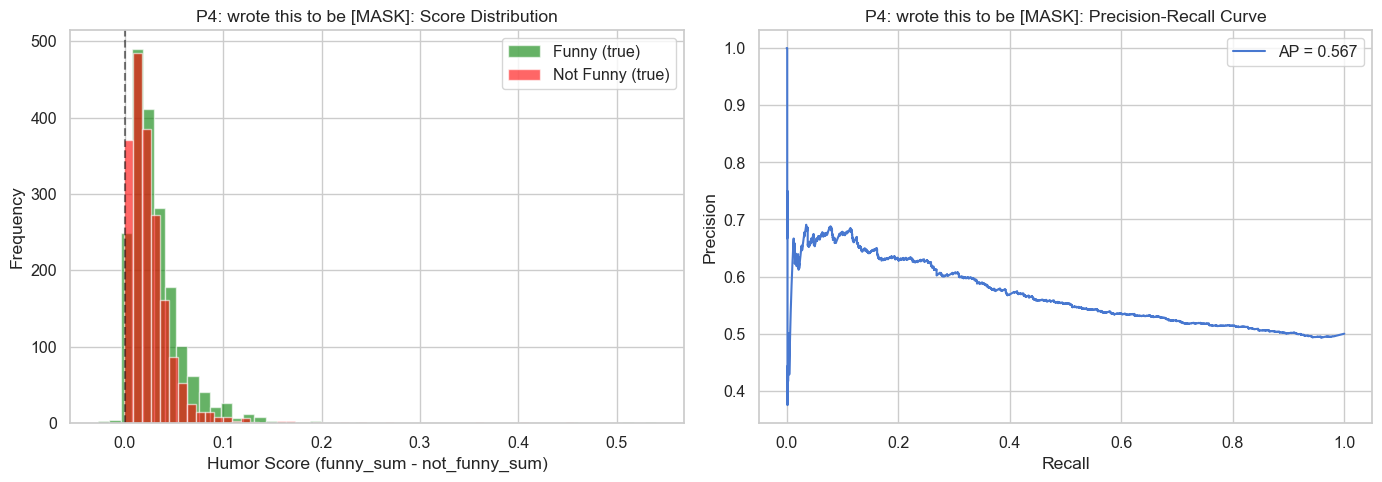

In [22]:
def evaluate_predictions(results, labels, funny_words, not_funny_words, prompt_name):
    """
    Evaluate how well the BERT predictions correlate with ground truth labels.
    
    Args:
        results: List of dicts from get_mask_predictions
        labels: Binary labels (0/1) or numeric funny scores
        funny_words: List of words indicating humor
        not_funny_words: List of words indicating lack of humor
        prompt_name: Name of the prompt for display
    
    Returns:
        Dictionary of evaluation metrics
    """
    # Extract prediction scores
    funny_sums = [r["funny_sum"] for r in results]
    not_funny_sums = [r["not_funny_sum"] for r in results]
    
    # Calculate humor score: funny_sum - not_funny_sum (or funny_sum / (funny_sum + not_funny_sum))
    humor_scores_diff = [f - nf for f, nf in zip(funny_sums, not_funny_sums)]
    humor_scores_ratio = [f / (f + nf + 1e-10) for f, nf in zip(funny_sums, not_funny_sums)]
    
    # Binary predictions using different thresholds
    binary_preds_diff = [1 if score > 0 else 0 for score in humor_scores_diff]
    binary_preds_ratio = [1 if score > 0.5 else 0 for score in humor_scores_ratio]
    
    # Compute metrics
    from scipy.stats import spearmanr, pearsonr
    
    metrics = {
        "prompt": prompt_name,
        # Correlation with labels
        "pearson_diff": pearsonr(humor_scores_diff, labels)[0],
        "spearman_diff": spearmanr(humor_scores_diff, labels)[0],
        "pearson_ratio": pearsonr(humor_scores_ratio, labels)[0],
        "spearman_ratio": spearmanr(humor_scores_ratio, labels)[0],
        # Binary classification metrics (if labels are binary)
        "f1_diff": f1_score(labels, binary_preds_diff) if set(labels) == {0, 1} else None,
        "f1_ratio": f1_score(labels, binary_preds_ratio) if set(labels) == {0, 1} else None,
        # AUC-ROC
        "roc_auc_diff": roc_auc_score(labels, humor_scores_diff) if set(labels) == {0, 1} else None,
        "roc_auc_ratio": roc_auc_score(labels, humor_scores_ratio) if set(labels) == {0, 1} else None,
        # Average precision
        "avg_precision_diff": average_precision_score(labels, humor_scores_diff) if set(labels) == {0, 1} else None,
        "avg_precision_ratio": average_precision_score(labels, humor_scores_ratio) if set(labels) == {0, 1} else None,
    }
    
    return metrics, humor_scores_diff, humor_scores_ratio


def compare_all_prompts(prompts_dict, sample):
    """
    Compare multiple prompts and rank them by performance.
    
    Args:
        prompts_dict: Dictionary of {prompt_name: (results, funny_words, not_funny_words)}
        sample: DataFrame with labels
    
    Returns:
        DataFrame with comparison metrics
    """
    all_metrics = []
    
    # Use binary label
    labels_binary = sample["label_is_funny_binary"].values
    
    # Or use numeric funny votes (uncomment to use instead)
    # labels_numeric = sample["review_votes_funny"].values
    
    for prompt_name, (results, funny_words, not_funny_words) in prompts_dict.items():
        metrics, _, _ = evaluate_predictions(results, labels_binary, funny_words, not_funny_words, prompt_name)
        all_metrics.append(metrics)
    
    comparison_df = pd.DataFrame(all_metrics)
    
    # Sort by best correlation or F1 score
    comparison_df = comparison_df.sort_values("roc_auc_ratio", ascending=False)
    
    return comparison_df


def plot_prediction_distributions(results, labels, prompt_name):
    """
    Plot the distribution of predictions separated by true label.
    """
    funny_sums = np.array([r["funny_sum"] for r in results])
    not_funny_sums = np.array([r["not_funny_sum"] for r in results])
    humor_scores = funny_sums - not_funny_sums
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution by label
    funny_mask = labels == 1
    axes[0].hist(humor_scores[funny_mask], bins=50, alpha=0.6, label="Funny (true)", color="green")
    axes[0].hist(humor_scores[~funny_mask], bins=50, alpha=0.6, label="Not Funny (true)", color="red")
    axes[0].set_xlabel("Humor Score (funny_sum - not_funny_sum)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"{prompt_name}: Score Distribution")
    axes[0].legend()
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
    
    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(labels, humor_scores)
    avg_precision = average_precision_score(labels, humor_scores)
    axes[1].plot(recall, precision, label=f"AP = {avg_precision:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{prompt_name}: Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


# Example usage:
# Create a dictionary of all your prompt experiments
prompts_comparison = {
    "P1: This review is [MASK]": (results_p1, funny_words1, not_funny_words1),
    "P2: meant to be [MASK]": (results_p2, funny_words1, not_funny_words1),
    "P3: find this [MASK]": (results_p3, funny_words1, not_funny_words1),
    "P4: wrote this to be [MASK]": (results_p4, funny_words1, not_funny_words1),
    "P5: trying to be [MASK]": (results_p5, funny_words1, not_funny_words1),
    "P6: written in a [MASK] way": (results_p6, funny_words1, not_funny_words1),
    "P7: is [MASK] funny": (results_p7, funny_words7, not_funny_words7),
}

# Compare all prompts
comparison_results = compare_all_prompts(prompts_comparison, sample)
print("\n=== PROMPT COMPARISON ===")
print(comparison_results.to_string(index=False))

# Plot the best performing prompt
best_prompt = comparison_results.iloc[0]["prompt"]
best_results, best_funny, best_not_funny = prompts_comparison[best_prompt]
plot_prediction_distributions(best_results, sample["label_is_funny_binary"].values, best_prompt)